# Assignment #5: Perceptron

This notebook implements two versions of the Perceptron algorithm:
- **Part 1**: Heuristic perceptron with sigmoid-based error update
- **Part 2**: Misclassification-based perceptron with log-loss tracking

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

# Load data
df = pd.read_csv('data.csv', header=None, names=['x1', 'x2', 'label'])
X = df[['x1', 'x2']].values
y = df['label'].values

print(f'Dataset shape: {X.shape}')
print(f'Class distribution: {np.bincount(y)}')
print(df.head())

Dataset shape: (100, 2)
Class distribution: [50 50]
        x1        x2  label
0  0.78051 -0.063669      1
1  0.28774  0.291390      1
2  0.40714  0.178780      1
3  0.29230  0.421700      1
4  0.50922  0.352560      1


## Data Visualization

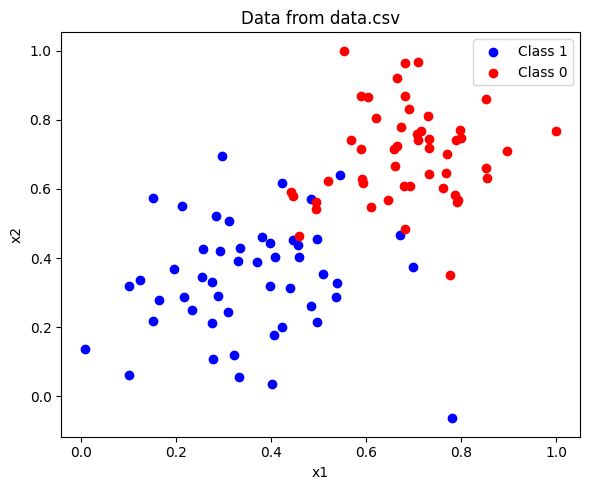

In [2]:
def plot_data(X, y, title='Dataset'):
    plt.figure(figsize=(6, 5))
    plt.scatter(X[y==1, 0], X[y==1, 1], color='blue', label='Class 1', zorder=3)
    plt.scatter(X[y==0, 0], X[y==0, 1], color='red',  label='Class 0', zorder=3)
    plt.xlabel('x1'); plt.ylabel('x2')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_data(X, y, 'Data from data.csv')

---
## Part 1 — Heuristic Perceptron

### Algorithm
1. Initialize random weights `w1, w2` and bias `b`.
2. For each point `(x1, x2)` with label `y`:
   - Compute sigmoid prediction: `ŷ = σ(w1·x1 + w2·x2 + b)`
   - Compute error: `e = y - ŷ`
   - Update: `b += r·e`, `wi += r·e·xi`
3. Repeat until error is small.

The **decision boundary** is where `w1·x1 + w2·x2 + b = 0`,  
so `x2 = -(w1·x1 + b) / w2`.

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def get_boundary_y(x_range, w1, w2, b):
    """Compute x2 values for the decision boundary line."""
    if abs(w2) < 1e-10:
        return None
    return -(w1 * x_range + b) / w2

def plot_boundary(ax, x_range, w1, w2, b, color='green', linestyle='--', alpha=0.5, lw=1):
    y_line = get_boundary_y(x_range, w1, w2, b)
    if y_line is not None:
        ax.plot(x_range, y_line, color=color, linestyle=linestyle, alpha=alpha, linewidth=lw)


def perceptron_heuristic(X, y, learning_rate=0.1, max_iter=100, tol=0.01, seed=42):
    """
    Heuristic Perceptron with sigmoid activation.
    Returns weight history for plotting.
    """
    np.random.seed(seed)
    w = np.random.randn(2) * 0.01
    b = np.random.randn() * 0.01

    history = [(w.copy(), b)]   # store (weights, bias) after each iteration
    n = len(X)

    for iteration in range(max_iter):
        total_error = 0
        for i in range(n):
            z    = np.dot(w, X[i]) + b
            y_hat = sigmoid(z)
            error = y[i] - y_hat
            b    += learning_rate * error
            w    += learning_rate * error * X[i]
            total_error += abs(error)

        history.append((w.copy(), b))

        if total_error / n < tol:
            print(f'Converged at iteration {iteration + 1} (avg error={total_error/n:.5f})')
            break
    else:
        print(f'Reached max iterations ({max_iter}), final avg error={total_error/n:.5f}')

    return history


def plot_heuristic_result(X, y, history, learning_rate, title='Solution boundary'):
    fig, ax = plt.subplots(figsize=(7, 6))

    # Scatter data
    ax.scatter(X[y==1, 0], X[y==1, 1], color='blue', zorder=5, label='Class 1')
    ax.scatter(X[y==0, 0], X[y==0, 1], color='red',  zorder=5, label='Class 0')

    x_range = np.linspace(-0.1, 1.1, 300)

    # Initial boundary — red
    w0, b0 = history[0]
    plot_boundary(ax, x_range, w0[0], w0[1], b0, color='red', linestyle='-', alpha=1.0, lw=1.5)

    # Intermediate boundaries — dashed green
    for w, b in history[1:-1]:
        plot_boundary(ax, x_range, w[0], w[1], b, color='green', linestyle='--', alpha=0.4, lw=0.8)

    # Final boundary — solid black
    wf, bf = history[-1]
    plot_boundary(ax, x_range, wf[0], wf[1], bf, color='black', linestyle='-', alpha=1.0, lw=2)

    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'{title}\nlr={learning_rate}, iterations={len(history)-1}')
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.legend()
    plt.tight_layout()
    plt.show()

### Part 1 — Learning Rate = 0.01

Reached max iterations (200), final avg error=0.19866


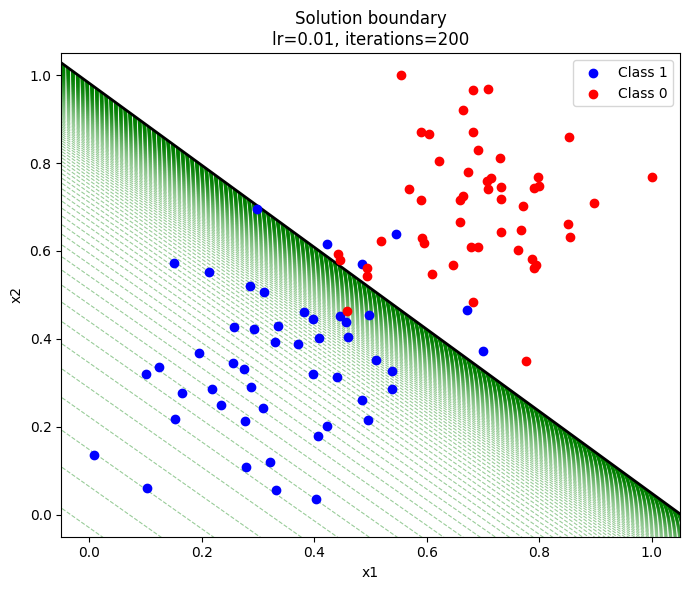

In [4]:
hist_001 = perceptron_heuristic(X, y, learning_rate=0.01, max_iter=200)
plot_heuristic_result(X, y, hist_001, learning_rate=0.01)

### Part 1 — Learning Rate = 0.1

Reached max iterations (200), final avg error=0.10244


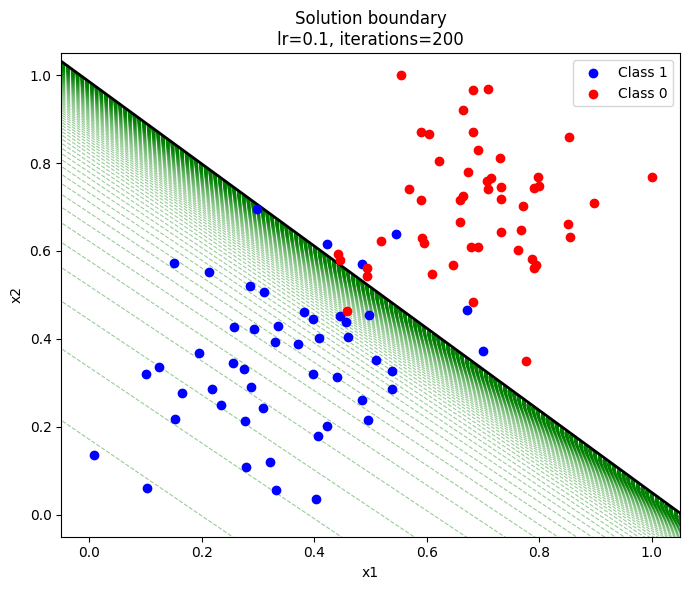

In [5]:
hist_01 = perceptron_heuristic(X, y, learning_rate=0.1, max_iter=200)
plot_heuristic_result(X, y, hist_01, learning_rate=0.1)

### Part 1 — Learning Rate = 1.0

Reached max iterations (200), final avg error=0.07658


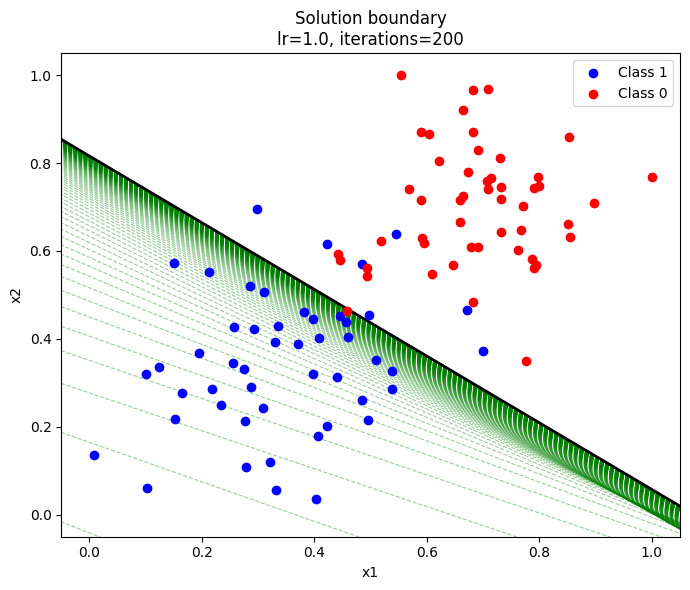

In [6]:
hist_1 = perceptron_heuristic(X, y, learning_rate=1.0, max_iter=200)
plot_heuristic_result(X, y, hist_1, learning_rate=1.0)

### Part 1 — Side-by-Side Comparison

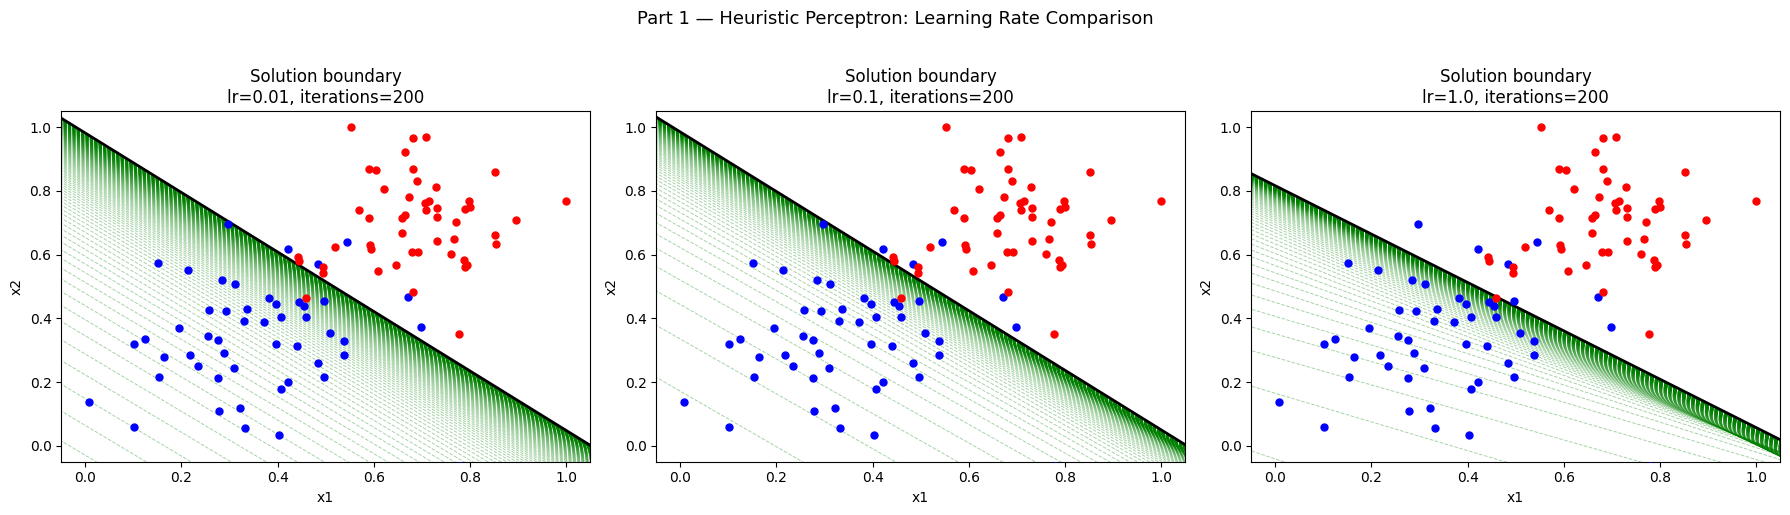

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x_range = np.linspace(-0.1, 1.1, 300)

configs = [
    (hist_001, 0.01),
    (hist_01,  0.1),
    (hist_1,   1.0),
]

for ax, (history, lr) in zip(axes, configs):
    ax.scatter(X[y==1, 0], X[y==1, 1], color='blue', zorder=5, s=25)
    ax.scatter(X[y==0, 0], X[y==0, 1], color='red',  zorder=5, s=25)

    # Initial — red
    w0, b0 = history[0]
    plot_boundary(ax, x_range, w0[0], w0[1], b0, color='red', linestyle='-', alpha=1.0, lw=1.5)

    # Intermediate — dashed green
    for w, b in history[1:-1]:
        plot_boundary(ax, x_range, w[0], w[1], b, color='green', linestyle='--', alpha=0.35, lw=0.7)

    # Final — black
    wf, bf = history[-1]
    plot_boundary(ax, x_range, wf[0], wf[1], bf, color='black', linestyle='-', alpha=1.0, lw=2)

    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'Solution boundary\nlr={lr}, iterations={len(history)-1}')
    ax.set_xlabel('x1'); ax.set_ylabel('x2')

plt.suptitle('Part 1 — Heuristic Perceptron: Learning Rate Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('part1_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

### Part 1 — Analysis

**Learning Rate = 0.01 (Small)**  
The perceptron takes small, careful steps with each update. The intermediate boundaries (dashed green) are numerous and tightly clustered, showing a slow but steady convergence toward the final solution. This produces a more stable search path but may require more iterations to converge.

**Learning Rate = 0.1 (Moderate)**  
A balanced trade-off between convergence speed and stability. The decision boundaries spread across the space but still converge reliably. This is generally the recommended starting learning rate for most datasets of this scale.

**Learning Rate = 1.0 (Large)**  
Large steps cause the boundary to swing dramatically in early iterations, visible as widely spread green dashed lines. The final boundary may still be reasonable, but the path is erratic. In some cases this can overshoot and cause oscillations around the optimal boundary.

**Conclusion**: A moderate learning rate (0.1) provides the best balance for this dataset. Too small slows learning; too large creates instability.

---
## Part 2 — Gradient Descent Perceptron

### Algorithm
1. Initialize random weights `w1, w2` and bias `b`.
2. For each point `(x1, x2)` with label `y`:
   - Classify using `ŷ = 1 if σ(w·x + b) ≥ 0.5 else 0`
   - If misclassified and `ŷ == 0`: `b += r`, `wi += r·xi`
   - If misclassified and `ŷ == 1`: `b -= r`, `wi -= r·xi`
3. Repeat for `n_epochs`.
4. Compute **log loss** every 10 epochs and plot the error curve.

In [8]:
def log_loss(X, y, w, b):
    """Compute mean binary cross-entropy (log loss)."""
    eps = 1e-15
    z = X @ w + b
    y_hat = sigmoid(z)
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))


def perceptron_gradient_descent(X, y, learning_rate=0.1, n_epochs=100, seed=42):
    """
    Gradient Descent Perceptron with binary classification (step function).
    Returns weight history and error history.
    """
    np.random.seed(seed)
    w = np.random.randn(2) * 0.01
    b = np.random.randn() * 0.01

    history     = [(w.copy(), b)]   # per-epoch boundary
    error_log   = []                # (epoch, loss) recorded every 10 epochs

    for epoch in range(n_epochs):
        for i in range(len(X)):
            z     = np.dot(w, X[i]) + b
            y_hat = 1 if sigmoid(z) >= 0.5 else 0

            if y_hat != y[i]:          # misclassified
                if y_hat == 0:         # predicted 0, true 1 → push up
                    b   += learning_rate
                    w   += learning_rate * X[i]
                else:                  # predicted 1, true 0 → push down
                    b   -= learning_rate
                    w   -= learning_rate * X[i]

        history.append((w.copy(), b))

        if (epoch + 1) % 10 == 0:
            loss = log_loss(X, y, w, b)
            error_log.append((epoch + 1, loss))

    return history, error_log


def plot_gd_result(X, y, history, error_log, learning_rate, n_epochs):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x_range = np.linspace(-0.1, 1.1, 300)
    ax = axes[0]

    ax.scatter(X[y==1, 0], X[y==1, 1], color='blue', zorder=5, label='Class 1')
    ax.scatter(X[y==0, 0], X[y==0, 1], color='red',  zorder=5, label='Class 0')

    # Initial — red
    w0, b0 = history[0]
    plot_boundary(ax, x_range, w0[0], w0[1], b0, color='red', linestyle='-', alpha=1.0, lw=1.5)

    # Intermediate — dashed green
    for w, b in history[1:-1]:
        plot_boundary(ax, x_range, w[0], w[1], b, color='green', linestyle='--', alpha=0.3, lw=0.7)

    # Final — black
    wf, bf = history[-1]
    plot_boundary(ax, x_range, wf[0], wf[1], bf, color='black', linestyle='-', alpha=1.0, lw=2)

    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'Solution boundary\nlr={learning_rate}, epochs={n_epochs}')
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.legend()

    # Error plot
    ax2 = axes[1]
    epochs_list = [e[0] for e in error_log]
    losses_list = [e[1] for e in error_log]
    ax2.plot(epochs_list, losses_list, color='steelblue', linewidth=2)
    ax2.set_xlabel('Number of epochs')
    ax2.set_ylabel('Error (Log Loss)')
    ax2.set_title('Error Plot')
    ax2.grid(True, alpha=0.3)

    plt.suptitle(f'Part 2 — Gradient Descent Perceptron  (lr={learning_rate})', fontsize=12)
    plt.tight_layout()
    plt.show()
    return wf, bf

### Part 2 — Learning Rate = 0.01, Epochs = 100

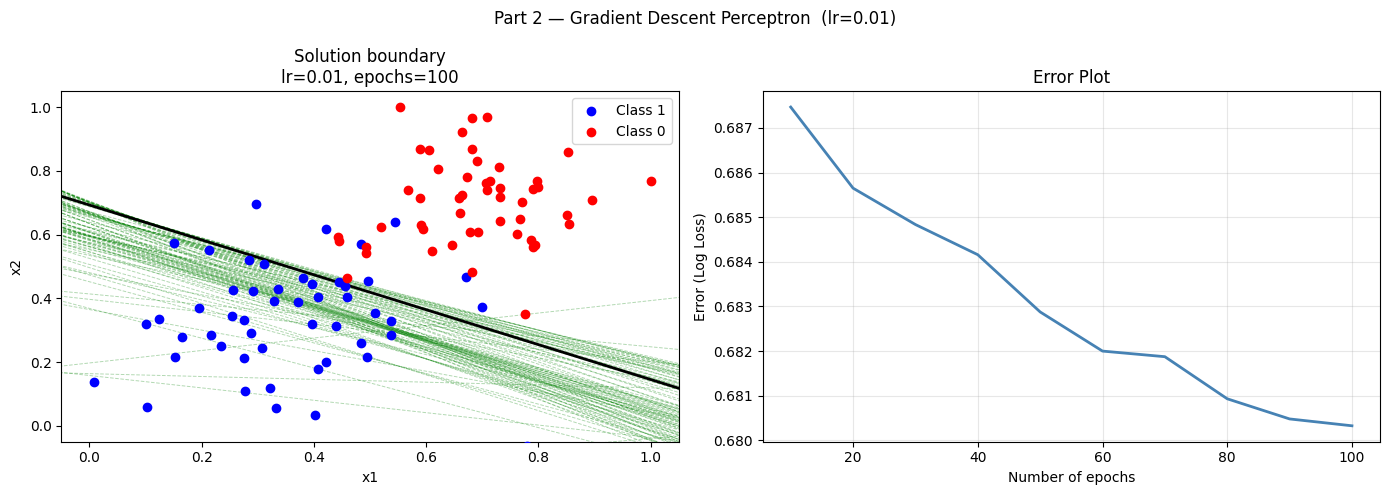

(array([-0.05253536, -0.09596781]), 0.06647688538100693)

In [9]:
hist2_001, err_001 = perceptron_gradient_descent(X, y, learning_rate=0.01, n_epochs=100)
plot_gd_result(X, y, hist2_001, err_001, learning_rate=0.01, n_epochs=100)

### Part 2 — Learning Rate = 0.1, Epochs = 100

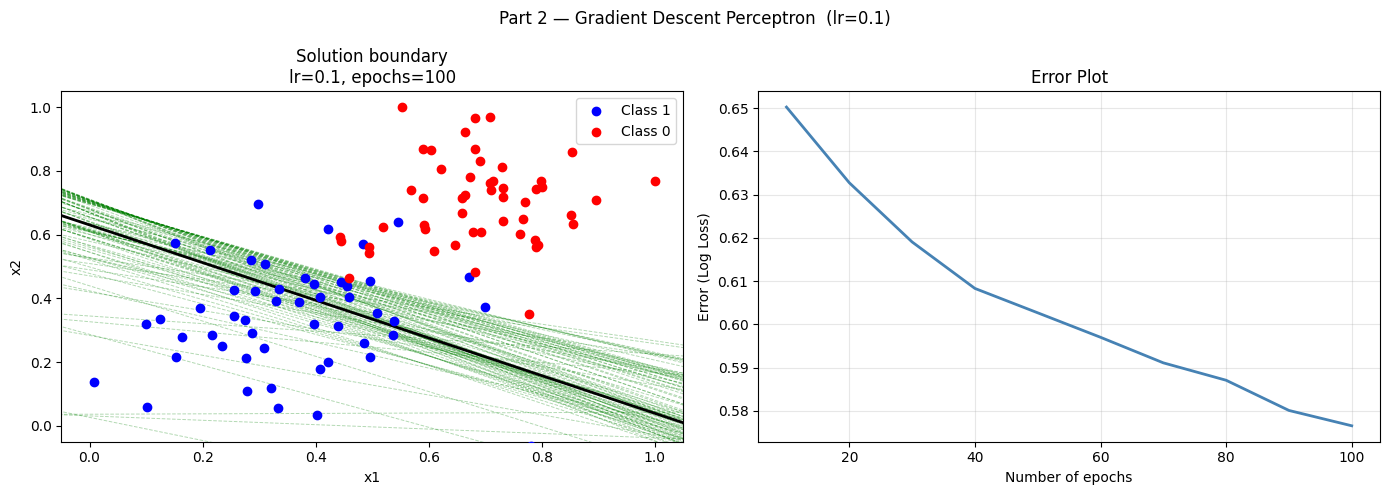

(array([-0.56874086, -0.96228734]), 0.6064768853810069)

In [10]:
hist2_01, err_01 = perceptron_gradient_descent(X, y, learning_rate=0.1, n_epochs=100)
plot_gd_result(X, y, hist2_01, err_01, learning_rate=0.1, n_epochs=100)

### Part 2 — Learning Rate = 1.0, Epochs = 100

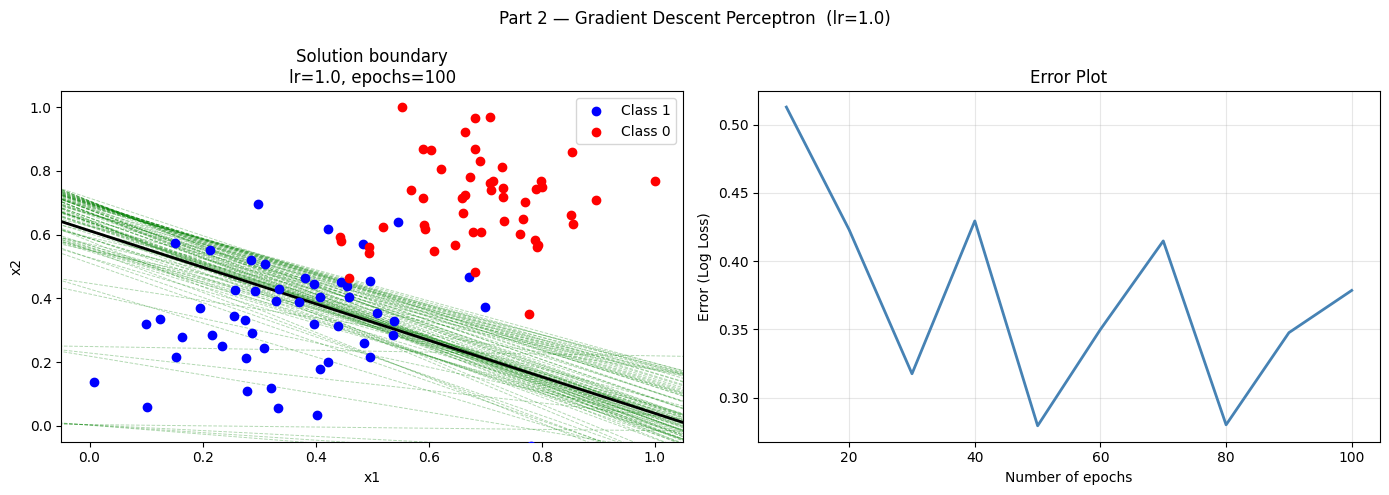

(array([-5.62371286, -9.81315864]), 6.006476885381007)

In [11]:
hist2_1, err_1 = perceptron_gradient_descent(X, y, learning_rate=1.0, n_epochs=100)
plot_gd_result(X, y, hist2_1, err_1, learning_rate=1.0, n_epochs=100)

### Part 2 — Effect of Epochs (lr=0.1)

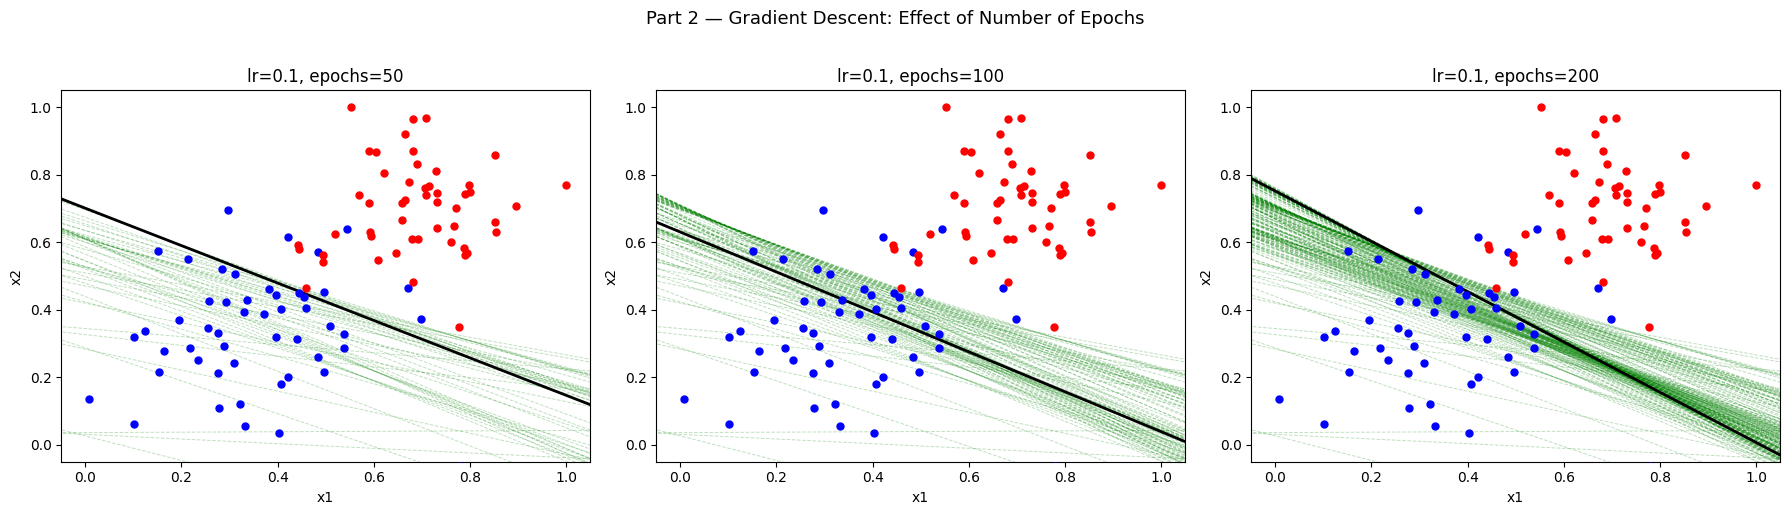

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x_range = np.linspace(-0.1, 1.1, 300)

epoch_configs = [50, 100, 200]

for ax, ep in zip(axes, epoch_configs):
    history, err = perceptron_gradient_descent(X, y, learning_rate=0.1, n_epochs=ep)

    ax.scatter(X[y==1, 0], X[y==1, 1], color='blue', zorder=5, s=25)
    ax.scatter(X[y==0, 0], X[y==0, 1], color='red',  zorder=5, s=25)

    w0, b0 = history[0]
    plot_boundary(ax, x_range, w0[0], w0[1], b0, color='red', linestyle='-', alpha=1.0, lw=1.5)
    for w, b in history[1:-1]:
        plot_boundary(ax, x_range, w[0], w[1], b, color='green', linestyle='--', alpha=0.25, lw=0.7)
    wf, bf = history[-1]
    plot_boundary(ax, x_range, wf[0], wf[1], bf, color='black', linestyle='-', alpha=1.0, lw=2)

    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'lr=0.1, epochs={ep}')
    ax.set_xlabel('x1'); ax.set_ylabel('x2')

plt.suptitle('Part 2 — Gradient Descent: Effect of Number of Epochs', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('part2_epochs_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

### Part 2 — Log Loss Comparison Across Learning Rates

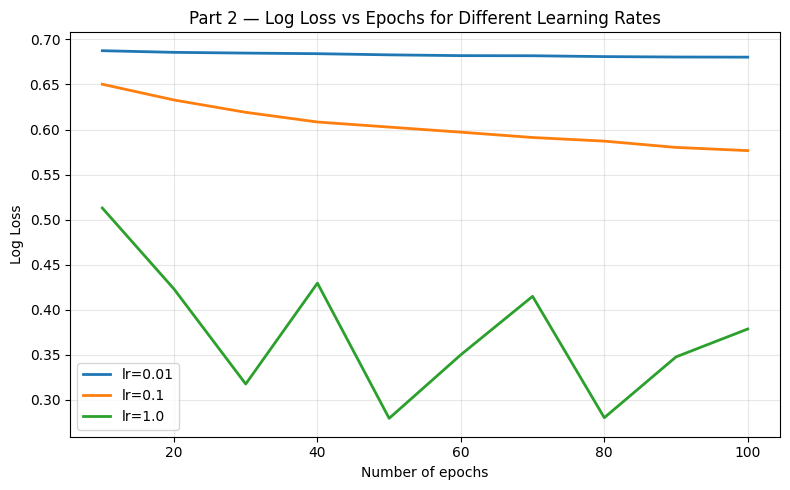

In [13]:
plt.figure(figsize=(8, 5))

for lr, err in [(0.01, err_001), (0.1, err_01), (1.0, err_1)]:
    epochs_list = [e[0] for e in err]
    losses_list = [e[1] for e in err]
    plt.plot(epochs_list, losses_list, label=f'lr={lr}', linewidth=2)

plt.xlabel('Number of epochs')
plt.ylabel('Log Loss')
plt.title('Part 2 — Log Loss vs Epochs for Different Learning Rates')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('part2_loss_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

### Part 2 — Analysis

**Learning Rate = 0.01 (Small)**  
The perceptron updates weights in small increments. The log loss decreases slowly but steadily. It requires more epochs to reach convergence but is very stable — no overshooting is observed.

**Learning Rate = 0.1 (Moderate)**  
Achieves a good balance between convergence speed and stability. The log loss curve drops quickly in early epochs and levels off smoothly, indicating reliable learning without erratic jumps. This is the best setting for this dataset.

**Learning Rate = 1.0 (Large)**  
Updates are very aggressive. The decision boundary changes dramatically between epochs (wide fan of green lines). While the loss may converge faster initially, it risks oscillation or instability, particularly if the data is not perfectly linearly separable.

**Effect of Epochs**  
With more epochs (50 → 100 → 200), the decision boundary becomes more refined. After ~100 epochs with lr=0.1, the boundary is well-positioned; additional epochs yield diminishing returns.

**Comparison with Part 1**  
- Part 1 (heuristic) uses the continuous sigmoid output `ŷ` directly for updates, making it smoother and more sensitive to small errors.
- Part 2 (GD) uses a binary step classification for updates, which is more decisive but may oscillate slightly if the boundary is near a data point.
- Both converge to similar final boundaries for well-separated data, but Part 1 is generally more principled from a gradient-descent perspective.